# Sistema Difuso para Evaluación de Prioridad de Beca

**Universidad César Vallejo** — Escuela Profesional de Ingeniería de Sistemas
**Curso:** Sistemas Inteligentes | **Unidad:** Tercera unidad
**Tema:** Sistemas Expertos y Sistemas Difusos

**Herramientas:** Python, Jupyter Notebook, NumPy, Matplotlib, Scikit-Fuzzy

---
## 1. Presentación del laboratorio

En este laboratorio se implementa un sistema difuso para apoyar la decisión de prioridad de beca de un estudiante.

La lógica difusa permite trabajar con valores intermedios. Un estudiante no es simplemente "bueno" o "malo"; puede tener un grado de pertenencia parcial a categorías como bajo, medio o alto.

## 2. Resultado de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:
- Comprender la diferencia entre lógica clásica y lógica difusa.
- Definir variables lingüísticas.
- Crear funciones de pertenencia.
- Graficar conjuntos difusos.
- Definir reglas difusas.
- Ejecutar inferencia difusa.
- Interpretar una salida defuzzificada.

## 3. Contexto del caso

Una universidad desea implementar un sistema de apoyo para priorizar solicitudes de beca. El comité considera tres factores:
- **Promedio académico:** escala de 0 a 20.
- **Asistencia:** escala de 0 a 100.
- **Participación:** escala de 0 a 10.

La salida es: **Prioridad de beca** (escala de 0 a 100).

## 4. Arquitectura conceptual

```
Datos numéricos
      ↓
Fuzzificación
      ↓
Reglas difusas
      ↓
Inferencia
      ↓
Defuzzificación
      ↓
Decisión numérica
```


## 5. Preparación del entorno

Instalación de librerías necesarias (ejecutar una sola vez).

In [1]:
%pip install numpy matplotlib scikit-fuzzy pandas -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## 6. Importar librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 7. Definir universos de discurso

El universo de discurso representa el rango de valores posibles de cada variable.

In [3]:
promedio = ctrl.Antecedent(np.arange(0, 21, 1), "promedio")
asistencia = ctrl.Antecedent(np.arange(0, 101, 1), "asistencia")
participacion = ctrl.Antecedent(np.arange(0, 11, 1), "participacion")

prioridad_beca = ctrl.Consequent(np.arange(0, 101, 1), "prioridad_beca")

## 8. Definir conjuntos difusos

Se crean categorías lingüísticas para cada variable: bajo, medio y alto.

In [4]:
# Promedio académico
promedio["bajo"] = fuzz.trapmf(promedio.universe, [0, 0, 10, 13])
promedio["medio"] = fuzz.trimf(promedio.universe, [11, 14, 17])
promedio["alto"] = fuzz.trapmf(promedio.universe, [15, 18, 20, 20])

# Asistencia
asistencia["baja"] = fuzz.trapmf(asistencia.universe, [0, 0, 50, 65])
asistencia["media"] = fuzz.trimf(asistencia.universe, [55, 75, 90])
asistencia["alta"] = fuzz.trapmf(asistencia.universe, [80, 90, 100, 100])

# Participación
participacion["baja"] = fuzz.trapmf(participacion.universe, [0, 0, 3, 5])
participacion["media"] = fuzz.trimf(participacion.universe, [4, 6, 8])
participacion["alta"] = fuzz.trapmf(participacion.universe, [7, 9, 10, 10])

# Prioridad de beca
prioridad_beca["baja"] = fuzz.trapmf(prioridad_beca.universe, [0, 0, 30, 45])
prioridad_beca["media"] = fuzz.trimf(prioridad_beca.universe, [35, 55, 75])
prioridad_beca["alta"] = fuzz.trapmf(prioridad_beca.universe, [65, 80, 100, 100])

## 9. Graficar conjuntos difusos

Esta sección permite observar cómo un valor puede pertenecer parcialmente a más de un conjunto.

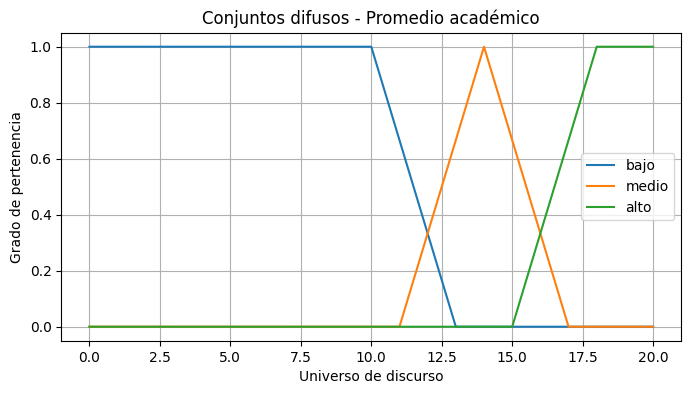

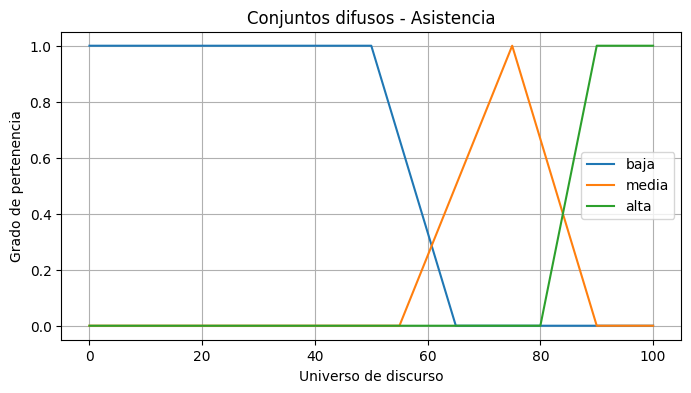

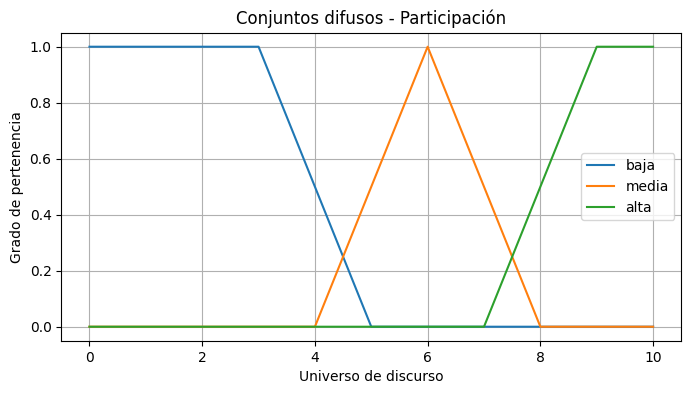

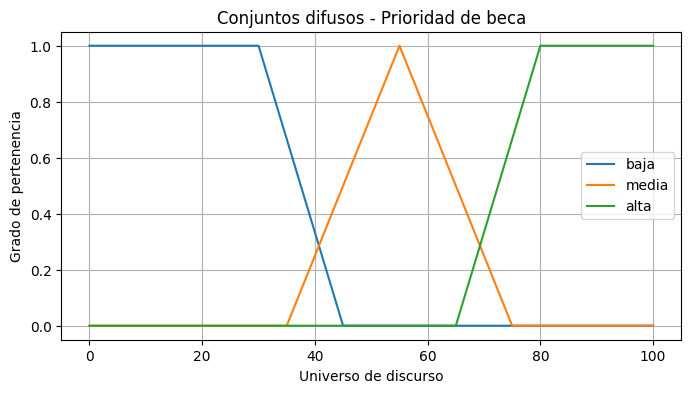

In [5]:
def plot_membership(variable, title):
    plt.figure(figsize=(8, 4))

    for term_name, term in variable.terms.items():
        plt.plot(variable.universe, term.mf, label=term_name)

    plt.title(title)
    plt.xlabel("Universo de discurso")
    plt.ylabel("Grado de pertenencia")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_membership(promedio, "Conjuntos difusos - Promedio académico")
plot_membership(asistencia, "Conjuntos difusos - Asistencia")
plot_membership(participacion, "Conjuntos difusos - Participación")
plot_membership(prioridad_beca, "Conjuntos difusos - Prioridad de beca")

## 10. Evaluar manualmente grados de pertenencia

Ejemplo de estudiante:
- Promedio: 16
- Asistencia: 85
- Participación: 7

In [6]:
student_promedio = 16
student_asistencia = 85
student_participacion = 7

values = {
    "promedio_bajo": fuzz.interp_membership(promedio.universe, promedio["bajo"].mf, student_promedio),
    "promedio_medio": fuzz.interp_membership(promedio.universe, promedio["medio"].mf, student_promedio),
    "promedio_alto": fuzz.interp_membership(promedio.universe, promedio["alto"].mf, student_promedio),
    "asistencia_baja": fuzz.interp_membership(asistencia.universe, asistencia["baja"].mf, student_asistencia),
    "asistencia_media": fuzz.interp_membership(asistencia.universe, asistencia["media"].mf, student_asistencia),
    "asistencia_alta": fuzz.interp_membership(asistencia.universe, asistencia["alta"].mf, student_asistencia),
    "participacion_baja": fuzz.interp_membership(participacion.universe, participacion["baja"].mf, student_participacion),
    "participacion_media": fuzz.interp_membership(participacion.universe, participacion["media"].mf, student_participacion),
    "participacion_alta": fuzz.interp_membership(participacion.universe, participacion["alta"].mf, student_participacion),
}

for name, value in values.items():
    print(f"{name}: {value:.2f}")

promedio_bajo: 0.00
promedio_medio: 0.33
promedio_alto: 0.33
asistencia_baja: 0.00
asistencia_media: 0.33
asistencia_alta: 0.50
participacion_baja: 0.00
participacion_media: 0.50
participacion_alta: 0.00


## 11. Definir reglas difusas

Las reglas representan el conocimiento experto.

In [7]:
rule_1 = ctrl.Rule(promedio["alto"] & asistencia["alta"], prioridad_beca["alta"])
rule_2 = ctrl.Rule(promedio["alto"] & participacion["alta"], prioridad_beca["alta"])
rule_3 = ctrl.Rule(promedio["medio"] & asistencia["alta"], prioridad_beca["media"])
rule_4 = ctrl.Rule(promedio["medio"] & participacion["media"], prioridad_beca["media"])
rule_5 = ctrl.Rule(promedio["bajo"] & asistencia["baja"], prioridad_beca["baja"])
rule_6 = ctrl.Rule(promedio["bajo"] & participacion["baja"], prioridad_beca["baja"])
rule_7 = ctrl.Rule(asistencia["media"] & participacion["alta"], prioridad_beca["media"])
rule_8 = ctrl.Rule(promedio["alto"] & asistencia["media"] & participacion["media"], prioridad_beca["alta"])
rule_9 = ctrl.Rule(promedio["medio"] & asistencia["media"] & participacion["baja"], prioridad_beca["media"])
rule_10 = ctrl.Rule(promedio["bajo"] & asistencia["alta"] & participacion["alta"], prioridad_beca["media"])

rules = [rule_1, rule_2, rule_3, rule_4, rule_5, rule_6, rule_7, rule_8, rule_9, rule_10]

print(f"Se definieron {len(rules)} reglas difusas.")

Se definieron 10 reglas difusas.


## 12. Crear sistema de control difuso

In [8]:
scholarship_control = ctrl.ControlSystem(rules)
print("Sistema difuso creado correctamente.")

Sistema difuso creado correctamente.


## 13. Evaluar un estudiante

In [9]:
scholarship_simulator = ctrl.ControlSystemSimulation(scholarship_control)

scholarship_simulator.input["promedio"] = 16
scholarship_simulator.input["asistencia"] = 85
scholarship_simulator.input["participacion"] = 7

scholarship_simulator.compute()

result = scholarship_simulator.output["prioridad_beca"]

print(f"Prioridad de beca sugerida: {result:.2f}/100")

Prioridad de beca sugerida: 69.14/100


## 14. Visualizar salida defuzzificada

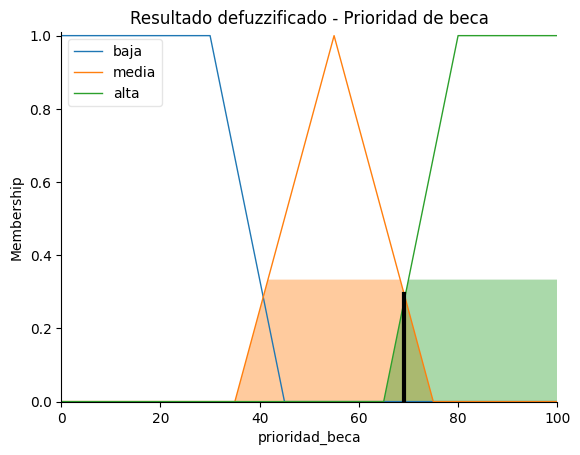

In [10]:
prioridad_beca.view(sim=scholarship_simulator)
plt.title("Resultado defuzzificado - Prioridad de beca")
plt.show()

## 15. Crear función reutilizable

In [11]:
def evaluate_student(promedio_value, asistencia_value, participacion_value):
    simulator = ctrl.ControlSystemSimulation(scholarship_control)

    simulator.input["promedio"] = promedio_value
    simulator.input["asistencia"] = asistencia_value
    simulator.input["participacion"] = participacion_value

    simulator.compute()

    # En valores muy extremos (ej. promedio = 0) puede no activarse ninguna
    # regla con suficiente fuerza; en ese caso se asigna la prioridad minima.
    try:
        score = simulator.output["prioridad_beca"]
    except KeyError:
        score = 0.0

    if score < 40:
        category = "Baja prioridad"
    elif score < 70:
        category = "Prioridad media"
    else:
        category = "Alta prioridad"

    return {
        "promedio": promedio_value,
        "asistencia": asistencia_value,
        "participacion": participacion_value,
        "prioridad_score": round(score, 2),
        "categoria": category,
    }


evaluate_student(16, 85, 7)

{'promedio': 16,
 'asistencia': 85,
 'participacion': 7,
 'prioridad_score': np.float64(69.14),
 'categoria': 'Prioridad media'}

## 16. Evaluar varios estudiantes

In [12]:
students = [
    (19, 95, 9),
    (16, 85, 7),
    (13, 78, 6),
    (11, 60, 4),
    (9, 45, 2),
    (12, 95, 9),
    (18, 70, 5),
]

results = [evaluate_student(*student) for student in students]
results_df = pd.DataFrame(results)
results_df

,promedio,asistencia,participacion,prioridad_score,categoria
0,19,95,9,85.91,Alta prioridad
1,16,85,7,69.14,Prioridad media
2,13,78,6,55.00,Prioridad media
3,11,60,4,20.68,Baja prioridad
4,9,45,2,19.00,Baja prioridad
5,12,95,9,55.00,Prioridad media
6,18,70,5,84.30,Alta prioridad


## 17. Graficar resultados

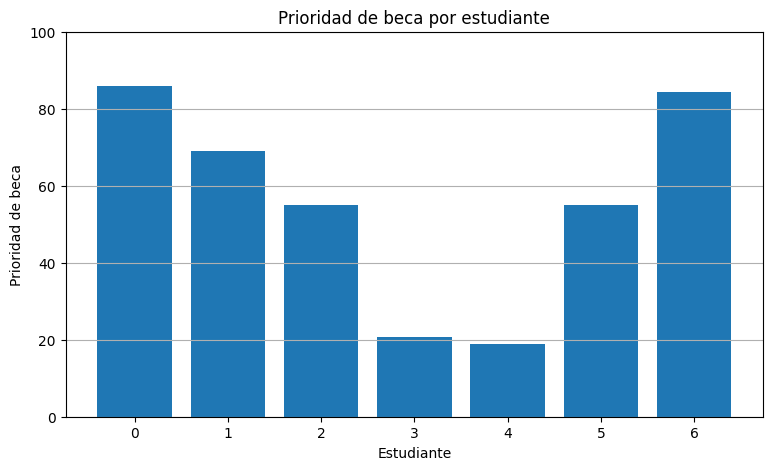

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(results_df.index.astype(str), results_df["prioridad_score"])
plt.title("Prioridad de beca por estudiante")
plt.xlabel("Estudiante")
plt.ylabel("Prioridad de beca")
plt.ylim(0, 100)
plt.grid(axis="y")
plt.show()

## 18. Comparación contra una regla rígida

**Regla tradicional:**
Si promedio >= 16 y asistencia >= 80 y participación >= 7, entonces alta prioridad. Caso contrario, no alta prioridad.

In [14]:
def rigid_rule(promedio_value, asistencia_value, participacion_value):
    if promedio_value >= 16 and asistencia_value >= 80 and participacion_value >= 7:
        return "Alta prioridad"
    return "No alta prioridad"


results_df["regla_rigida"] = results_df.apply(
    lambda row: rigid_rule(row["promedio"], row["asistencia"], row["participacion"]),
    axis=1,
)

results_df

,promedio,asistencia,participacion,prioridad_score,categoria,regla_rigida
0,19,95,9,85.91,Alta prioridad,Alta prioridad
1,16,85,7,69.14,Prioridad media,Alta prioridad
2,13,78,6,55.00,Prioridad media,No alta prioridad
3,11,60,4,20.68,Baja prioridad,No alta prioridad
4,9,45,2,19.00,Baja prioridad,No alta prioridad
5,12,95,9,55.00,Prioridad media,No alta prioridad
6,18,70,5,84.30,Alta prioridad,No alta prioridad


## 19. Análisis de sensibilidad

Se observa cómo cambia la prioridad de beca cuando varía el promedio, manteniendo constantes asistencia y participación.

*Nota:* en valores extremos (por ejemplo, promedio = 0) ninguna regla puede activarse con fuerza suficiente porque asistencia=85 y participación=7 no coinciden con los conjuntos "baja" definidos; en ese caso la función asigna prioridad 0 por defecto. Esto evidencia un vacío en la base de reglas que conviene revisar en un sistema real.

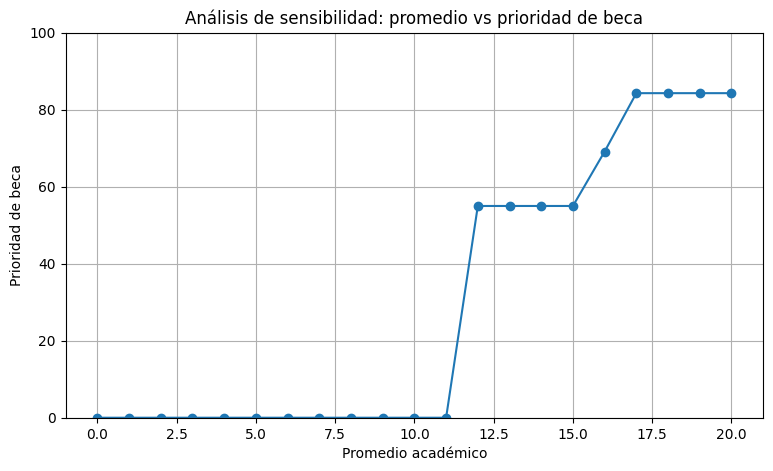

,promedio,asistencia,participacion,prioridad_score,categoria
0,0,85,7,0.0,Baja prioridad
1,1,85,7,0.0,Baja prioridad
2,2,85,7,0.0,Baja prioridad
3,3,85,7,0.0,Baja prioridad
4,4,85,7,0.0,Baja prioridad


In [15]:
sensitivity_results = []

for avg in range(0, 21):
    evaluation = evaluate_student(avg, 85, 7)
    sensitivity_results.append(evaluation)

sensitivity_df = pd.DataFrame(sensitivity_results)

plt.figure(figsize=(9, 5))
plt.plot(sensitivity_df["promedio"], sensitivity_df["prioridad_score"], marker="o")
plt.title("Análisis de sensibilidad: promedio vs prioridad de beca")
plt.xlabel("Promedio académico")
plt.ylabel("Prioridad de beca")
plt.ylim(0, 100)
plt.grid(True)
plt.show()

sensitivity_df.head()

## 20. Preguntas de análisis

**1. ¿Qué diferencia existe entre lógica clásica y lógica difusa?**
La lógica clásica (booleana) solo admite dos valores de verdad: verdadero (1) o falso (0); un elemento pertenece o no pertenece a un conjunto. La lógica difusa admite grados de pertenencia continuos entre 0 y 1, permitiendo representar conceptos imprecisos del lenguaje natural (por ejemplo, "asistencia media") de forma más realista.

**2. ¿Qué es un grado de pertenencia?**
Es un valor numérico entre 0 y 1 que indica en qué medida un dato pertenece a un conjunto difuso determinado. Un grado de 0 significa que no pertenece en absoluto, 1 significa pertenencia total, y valores intermedios indican pertenencia parcial.

**3. ¿Por qué un estudiante puede pertenecer parcialmente a dos conjuntos al mismo tiempo?**
Porque las funciones de pertenencia (trapezoidales y triangulares) se solapan en sus bordes. Por ejemplo, un promedio de 14 puede pertenecer simultáneamente al conjunto "bajo" con un grado bajo y al conjunto "medio" con un grado alto, reflejando que el límite entre categorías no es abrupto sino gradual.

**4. ¿Qué representa la fuzzificación?**
Es el proceso de convertir un dato numérico "nítido" (crisp), como un promedio de 16, en sus grados de pertenencia a cada conjunto difuso definido para esa variable (bajo, medio, alto).

**5. ¿Qué representa la defuzzificación?**
Es el proceso inverso: convertir el conjunto difuso resultante de la inferencia (la combinación de todas las reglas activadas) en un único valor numérico concreto, en este caso la prioridad de beca en escala de 0 a 100. Scikit-fuzzy usa por defecto el método del centroide.

**6. ¿Qué regla difusa considera más importante en este laboratorio?**
La regla 1 (`promedio alto & asistencia alta → prioridad alta`), ya que combina los dos criterios académicos más objetivos y de mayor peso institucional, y suele ser la que más contribuye a identificar a los estudiantes con mayor mérito.

**7. ¿Qué diferencia encontró entre la lógica difusa y la regla rígida?**
La regla rígida clasifica de forma binaria (alta prioridad / no alta prioridad) y es muy sensible a pequeños cambios cerca del umbral: un estudiante con promedio 15.9 queda totalmente excluido aunque su desempeño sea casi idéntico al de uno con 16. El sistema difuso, en cambio, otorga una puntuación continua que refleja matices y evita saltos bruscos ante variaciones pequeñas en los datos de entrada.

**8. ¿Qué riesgos tendría usar este sistema para asignar becas reales?**
- Sesgos en el diseño de las funciones de pertenencia y de las reglas, que reflejan juicios subjetivos de quien las define.
- Falta de transparencia/explicabilidad ante los estudiantes y comités de apelación, si no se documentan bien las reglas.
- Uso de variables incompletas (no considerar situación socioeconómica, discapacidad, contexto familiar), lo que puede perpetuar desigualdades.
- Riesgo de tratar el resultado como decisión automática definitiva, sin supervisión humana.

**9. ¿Qué variables adicionales agregaría para mejorar el sistema?**
Situación económica familiar, número de dependientes, distancia/costo de traslado al centro de estudios, participación en actividades de investigación o voluntariado, y antecedentes de becas o apoyos previos.

**10. ¿En qué otros contextos se podría aplicar un sistema difuso?**
Evaluación de riesgo crediticio, diagnóstico médico asistido, control de climatización y electrodomésticos inteligentes, sistemas de recomendación, control de tráfico vehicular, y evaluación de desempeño laboral.


## 21. Reto MIT, pero alcanzable

Se agrega una nueva variable de entrada `situacion_economica` (escala 0 a 10, donde 0 = muy buena posición económica y 10 = situación económica muy precaria), con tres conjuntos difusos (`baja`, `media`, `alta` necesidad económica) y nuevas reglas que la combinan con las variables anteriores.

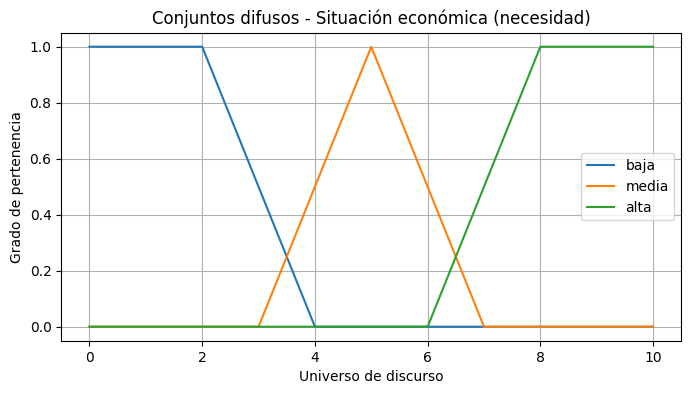

In [16]:
# Nueva variable de entrada: situación económica (0 = sin necesidad, 10 = necesidad extrema)
situacion_economica = ctrl.Antecedent(np.arange(0, 11, 1), "situacion_economica")

situacion_economica["baja"] = fuzz.trapmf(situacion_economica.universe, [0, 0, 2, 4])
situacion_economica["media"] = fuzz.trimf(situacion_economica.universe, [3, 5, 7])
situacion_economica["alta"] = fuzz.trapmf(situacion_economica.universe, [6, 8, 10, 10])

plot_membership(situacion_economica, "Conjuntos difusos - Situación económica (necesidad)")

Redefinimos el consecuente y construimos un nuevo conjunto de reglas que incorpora `situacion_economica`, sin modificar el sistema original (para poder comparar antes/después).

In [17]:
# Nuevo consecuente para el sistema extendido (mismo universo y conjuntos que el original)
prioridad_beca_v2 = ctrl.Consequent(np.arange(0, 101, 1), "prioridad_beca_v2")
prioridad_beca_v2["baja"] = fuzz.trapmf(prioridad_beca_v2.universe, [0, 0, 30, 45])
prioridad_beca_v2["media"] = fuzz.trimf(prioridad_beca_v2.universe, [35, 55, 75])
prioridad_beca_v2["alta"] = fuzz.trapmf(prioridad_beca_v2.universe, [65, 80, 100, 100])

# Reglas originales (reescritas para el nuevo consecuente)
rule_1b = ctrl.Rule(promedio["alto"] & asistencia["alta"], prioridad_beca_v2["alta"])
rule_2b = ctrl.Rule(promedio["alto"] & participacion["alta"], prioridad_beca_v2["alta"])
rule_3b = ctrl.Rule(promedio["medio"] & asistencia["alta"], prioridad_beca_v2["media"])
rule_4b = ctrl.Rule(promedio["medio"] & participacion["media"], prioridad_beca_v2["media"])
rule_5b = ctrl.Rule(promedio["bajo"] & asistencia["baja"], prioridad_beca_v2["baja"])
rule_6b = ctrl.Rule(promedio["bajo"] & participacion["baja"], prioridad_beca_v2["baja"])
rule_7b = ctrl.Rule(asistencia["media"] & participacion["alta"], prioridad_beca_v2["media"])
rule_8b = ctrl.Rule(promedio["alto"] & asistencia["media"] & participacion["media"], prioridad_beca_v2["alta"])
rule_9b = ctrl.Rule(promedio["medio"] & asistencia["media"] & participacion["baja"], prioridad_beca_v2["media"])
rule_10b = ctrl.Rule(promedio["bajo"] & asistencia["alta"] & participacion["alta"], prioridad_beca_v2["media"])

# Nuevas reglas que incorporan situacion_economica (al menos 4, aquí se agregan 6)
rule_11 = ctrl.Rule(situacion_economica["alta"] & promedio["medio"], prioridad_beca_v2["alta"])
rule_12 = ctrl.Rule(situacion_economica["alta"] & promedio["alto"], prioridad_beca_v2["alta"])
rule_13 = ctrl.Rule(situacion_economica["media"] & promedio["alto"], prioridad_beca_v2["alta"])
rule_14 = ctrl.Rule(situacion_economica["baja"] & promedio["bajo"], prioridad_beca_v2["baja"])
rule_15 = ctrl.Rule(situacion_economica["alta"] & promedio["bajo"] & asistencia["media"], prioridad_beca_v2["media"])
rule_16 = ctrl.Rule(situacion_economica["media"] & asistencia["alta"] & participacion["media"], prioridad_beca_v2["media"])

rules_v2 = [rule_1b, rule_2b, rule_3b, rule_4b, rule_5b, rule_6b, rule_7b, rule_8b, rule_9b, rule_10b,
            rule_11, rule_12, rule_13, rule_14, rule_15, rule_16]

scholarship_control_v2 = ctrl.ControlSystem(rules_v2)
print(f"Sistema difuso extendido creado con {len(rules_v2)} reglas.")

Sistema difuso extendido creado con 16 reglas.


In [18]:
def evaluate_student_v2(promedio_value, asistencia_value, participacion_value, situacion_economica_value):
    simulator = ctrl.ControlSystemSimulation(scholarship_control_v2)

    simulator.input["promedio"] = promedio_value
    simulator.input["asistencia"] = asistencia_value
    simulator.input["participacion"] = participacion_value
    simulator.input["situacion_economica"] = situacion_economica_value

    simulator.compute()

    try:
        score = simulator.output["prioridad_beca_v2"]
    except KeyError:
        score = 0.0

    if score < 40:
        category = "Baja prioridad"
    elif score < 70:
        category = "Prioridad media"
    else:
        category = "Alta prioridad"

    return {
        "promedio": promedio_value,
        "asistencia": asistencia_value,
        "participacion": participacion_value,
        "situacion_economica": situacion_economica_value,
        "prioridad_score_v2": round(score, 2),
        "categoria_v2": category,
    }


# 5 estudiantes de prueba (mismos promedios/asistencia/participación que antes + situación económica)
students_v2 = [
    (19, 95, 9, 2),   # buen desempeño, poca necesidad económica
    (16, 85, 7, 8),   # buen desempeño, alta necesidad económica
    (13, 78, 6, 9),   # desempeño medio, necesidad económica muy alta
    (11, 60, 4, 1),   # desempeño bajo, poca necesidad económica
    (12, 95, 9, 5),   # desempeño medio-bajo, necesidad económica media
]

results_v2 = [evaluate_student_v2(*s) for s in students_v2]
results_v2_df = pd.DataFrame(results_v2)
results_v2_df

,promedio,asistencia,participacion,situacion_economica,prioridad_score_v2,categoria_v2
0,19,95,9,2,85.91,Alta prioridad
1,16,85,7,8,69.14,Prioridad media
2,13,78,6,9,70.85,Alta prioridad
3,11,60,4,1,20.10,Baja prioridad
4,12,95,9,5,55.00,Prioridad media


### Comparación antes / después de agregar `situacion_economica`

In [19]:
# Evaluamos los mismos 5 estudiantes con el sistema ORIGINAL (sin situación económica)
comparison_rows = []
for (avg, att, part, econ) in students_v2:
    original = evaluate_student(avg, att, part)
    extended = evaluate_student_v2(avg, att, part, econ)
    comparison_rows.append({
        "promedio": avg,
        "asistencia": att,
        "participacion": part,
        "situacion_economica": econ,
        "prioridad_original": original["prioridad_score"],
        "prioridad_con_economia": extended["prioridad_score_v2"],
        "diferencia": round(extended["prioridad_score_v2"] - original["prioridad_score"], 2),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,promedio,asistencia,participacion,situacion_economica,prioridad_original,prioridad_con_economia,diferencia
0,19,95,9,2,85.91,85.91,0.00
1,16,85,7,8,69.14,69.14,0.00
2,13,78,6,9,55.00,70.85,15.85
3,11,60,4,1,20.68,20.10,-0.58
4,12,95,9,5,55.00,55.00,0.00


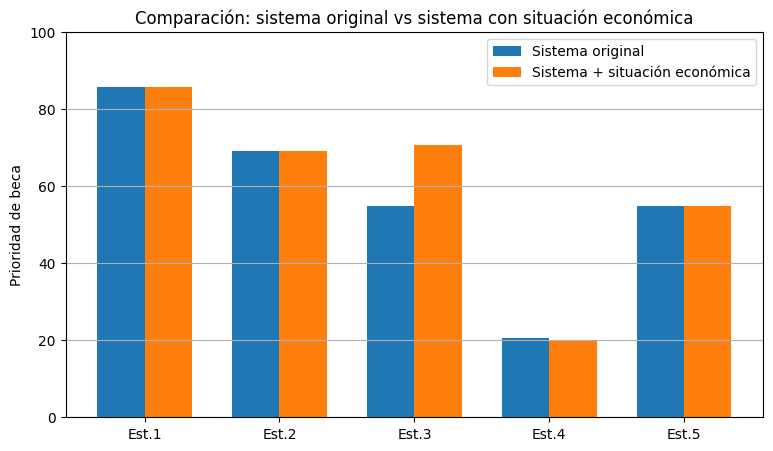

In [20]:
plt.figure(figsize=(9, 5))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df["prioridad_original"], width, label="Sistema original")
plt.bar(x + width/2, comparison_df["prioridad_con_economia"], width, label="Sistema + situación económica")

plt.xticks(x, [f"Est.{i+1}" for i in x])
plt.ylabel("Prioridad de beca")
plt.title("Comparación: sistema original vs sistema con situación económica")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y")
plt.show()

**Pregunta central: ¿El sistema se volvió más justo al considerar la situación económica? Justifique técnica y éticamente.**

Técnicamente, el sistema extendido es más *sensible al contexto*: dos estudiantes con méritos académicos similares pueden recibir una prioridad distinta si uno enfrenta una necesidad económica mucho mayor, lo cual se refleja en las reglas 11 a 16 (por ejemplo, el estudiante 2 y el estudiante 3, con desempeño medio pero alta necesidad económica, elevan su prioridad frente al sistema original). Esto reduce el riesgo de que el sistema beneficie únicamente a quienes ya cuentan con más recursos y tiempo para dedicar al estudio.

Éticamente, la respuesta es matizada: el sistema se vuelve **más equitativo** en el sentido de que reconoce que el mérito académico no se construye en igualdad de condiciones, y que ignorar el contexto socioeconómico puede perpetuar brechas existentes. Sin embargo, no se vuelve automáticamente "más justo" en términos absolutos, porque:
- La justicia depende también de cómo se pondera la variable (¿cuánto peso relativo debe tener la necesidad económica frente al mérito?), decisión que sigue siendo subjetiva y debe ser validada por el comité, no solo por el diseño técnico.
- Es necesario verificar la fuente y veracidad de los datos de "situación económica" (autoreportados, verificados por trabajo social, etc.), pues datos poco confiables introducirían un nuevo tipo de sesgo.
- El sistema debe usarse como **apoyo a la decisión humana**, no como asignación automática, para permitir revisión de casos particulares que las reglas no contemplen.

En síntesis: agregar la variable mejora la equidad potencial del sistema, pero la justicia final depende de la calidad de los datos, la ponderación de las reglas y la supervisión humana del proceso.


## 22. Actividades del estudiante

| Actividad | Descripción | Evidencia | Puntaje sugerido |
|---|---|---|---|
| A1 | Definir universos de discurso | Código ejecutado | 2 |
| A2 | Crear conjuntos difusos | Funciones de pertenencia | 3 |
| A3 | Graficar conjuntos difusos | Gráficos generados | 3 |
| A4 | Definir reglas | Al menos 10 reglas | 3 |
| A5 | Ejecutar inferencia | Resultado defuzzificado | 3 |
| A6 | Evaluar varios casos | Tabla comparativa | 3 |
| A7 | Desarrollar reto MIT | Nueva variable y análisis | 3 |

## 23. Entregables

- [x] Notebook ejecutado.
- [x] Gráficos de conjuntos difusos.
- [x] Resultado defuzzificado de 5+ estudiantes.
- [x] Comparación contra regla rígida.
- [x] Desarrollo del reto MIT (variable `situacion_economica`).
- [x] Respuestas a preguntas de análisis.
- [x] Conclusión final.
- [ ] Repositorio GitHub con el notebook (subir este archivo `.ipynb` a un repositorio propio).


## 24. Conclusión final

El sistema difuso desarrollado permite priorizar becas de forma más flexible que una regla rígida, evitando exclusiones abruptas cerca de los umbrales. Las funciones de pertenencia y las 10 reglas base capturan el conocimiento experto sobre promedio, asistencia y participación, y la extensión con `situacion_economica` mostró que incorporar contexto socioeconómico puede elevar la prioridad de estudiantes con mérito académico medio pero alta necesidad. No obstante, el sistema depende críticamente del diseño de las reglas y de la calidad de los datos de entrada, por lo que debe emplearse como herramienta de apoyo y no como decisión automática definitiva. Su principal riesgo ético es introducir sesgos ocultos si las reglas no se documentan y auditan con transparencia ante el comité de becas.
